Hopefully you enjoyed the Intro to Machine Learning. Let's dive into **neural networks!**


# What is Deep Learning? #

Okay, so if that's what machine learning is, what is **deep learning**? Deep learning is a kind of machine learning that takes inspiration from the brain. It uses simple **neurons** that communicate with each other to build a larger **neural network**. Despite each neuron being simple by itself, they combine to exhibit complex behaviour. Your brain 🧠 contains ~86 billion neurons, and you can do lots of complex things!

If you want to understand why neural networks are so powerful from a mathematical perspective, you can read about the *Universal Approximation Theorem* [here ](https://towardsdatascience.com/neural-networks-and-the-universal-approximation-theorem-8a389a33d30a) or watch a short visualisation [here.](https://www.youtube.com/watch?v=Ln8pV1AXAgQ)

Most of the hype around artificial intelligence in recent years has been in **deep learning**. Natural language tasks like translation, summarisation, chatbot generation or image generation and recognition are just some of the tasks where deep learning models have neared or even exceeded human-level performance.


# A Single Neuron ⚪

A single neuron is just a function. It takes in an input, and spits out an output. We choose this function to be a straight line. Therefore, a nueron has two **parameters**: its **weight, w,** and its **bias, b**. The input is multiplied by the weight, and then added to the bias, and the result is passed forwards.

<figure style="padding: 1em;">
<img src="https://storage.googleapis.com/kaggle-media/learn/images/mfOlDR6.png" width="250" alt="Diagram of a linear unit.">

</figure>

Let's see how to make one in Pytorch 🔨


In [ ]:
# Let's import torch as well as the nn module
import torch
from torch import nn

# TODO: Create A layer of neurons with 1 input and 1 output (i.e. a single neuron)
layer = nn.Linear(...)

# TODO: Let's print the neuron (layer) and its parameters (.weight and .bias)
print(...)
print(...)
print(...)

The parameters are just random values to begin with. If you want to know what kind of random values there are, you can check out [the docs](https://pytorch.org/docs/stable/generated/torch.nn.Linear.html).

**Think🤔**:Try changing the arguments of `nn.Linear()` to have more than one input and output. What changed? What's the data type of `layer.weight`? and `layer.bias`?

**Extension😈**: A bit tougher - any idea what `requires_grad` means? Why do you think it's set to `True`? Can you think of a reason you might want to set it to `False`?

Now let's run a value through the neuron by simply 'calling' the object. (You can also call `.forward()`, but this is worse practice). We get the output as a *tensor*.

**Tensors**: Don't be scared - this is just a fancy name for a list with more than one dimension. We use this word like how we use the word *matrix* for 2D arrays, but tensors can have any number of dimensions. For a tensor containing one value, you can call `.item()` to just get the number out.

In [ ]:
# Ceate a tensor (fancy name for a multi-dimensional array) with a single value
x = torch.tensor([1.0])

# TODO: Let's apply the neuron to the tensor
y = ...

# TODO: Let's print the result as just a number
print(...)

# Layers of Neurones

A single layer isn't very cool. Let's add more layers. We do that with `nn.Sequential` to apply a sequence of functions, one after another.

But first! - we can't just add layers upon layers of straight lines or else we will only be making more straight lines. We need to add some **non-linearity** to our model with an **activation function**. We use `nn.ReLU()` as it is the most common, but it is not the only choice. `ReLU` is just the `max(0, input)` function, and it makes straight lines become straight lines with corners.

**Think🤔**: Can you draw the graph of the ReLU function with a straight line as its input? How about the ReLU function for a sine wave?

**Extension😈**: Can you think of other ways you might add non-linearity to your model (without changing the neuron)? What might be sensible? Go do some research to see what else is used!

In [ ]:
# We stack layers with torch.nn.Sequential
# We can also add activation functions
# TODO: Add linear layers that take 1 input to 3 outputs and 3 inputs to 1 output, with a ReLU activation function in between
model = nn.Sequential(
    ...,
    ...,
    ...
)

# Let's print the model
print(model)

**Extension😈**: Can you draw the model above? How many 'layers' are there really? How many parameters (weights and biases)? So how many 'neurons' are there? Was I lying when I said that a neuron is a straight line? Can you give a more precise definition?

# Training A Neural Network 🎓

### Loss Function 📉

To train a neural network, you need 2 things: a **loss function** and an **optimiser**.

A **loss function**  decides how good a job your model did. The lower it is, the better. Through training, the loss should go down, indicating that the model is getting better at the task. P.S. it can also be called the error function or objective function. Hopefully these names make intuitive sense to you!

For example, in the lecture we had an input of 1 and a desired output of 2. We ran the model and got an output of 0. We could score this with a loss function of:

$\text{Loss}(\text{model output}, \text{desired output}) = |\text{model output} - \text{desired output}|$

or in more mathematical language:

$\text{L}(\hat{y}, y) = |\hat{y} - y|$

where $y$ is the desired output and $\hat{y}$ is the model's guess.

**Think🤔**: Why is the absolute value there?

*Hint: Imagine the absolute value wasn't there. What would happen if the model predicted 5 and you wanted it to predict 10?*

For a real world example, if we wanted our model to predict the next word, we could define a loss function that scores 0 if the next word is correct and 1 if it is incorrect. Minimising this would mean that the model always outputs the correct next word - ideal! This is not conceptually too far from what is actually done in practice.

### Optimiser 🏋️‍♀️

An **optimiser** decides how to change the parameters of the model to do a better job next time. After the loss has been calculated, it goes in and updates the parameters in the model so that the model gets closer to the desired output.

It does this by going backwards through the model, looking at each parameter, and seeing whether you should increase or decrease that parameter in order to make the loss smaller.

The optimiser doesn't just look at the direction, it also looks at how much to change each parameter by. It does this by determining how sensitive the loss is to changes of each parameter. For maths nerds: it does this using derivatives and the chain rule i.e. the gradient of the loss function w.r.t. the parameter. It also multiplies this number by a *learning rate* which is generally set to somewhere between 0.01 and 0.00001, depending on the task, model and loss function. This is a *hyperparameter* of our NN (Neural Network) - it's set by you to guide the ML algorithm to do a better job.

**Think🤔**: Why do you think these processes are called **gradient descent** and **backpropagation**? Why is it called a **learning rate**?

**Think🤔**: What do you think changing the learning rate does? What happens if it's too small? Or too big? You can test your intuition in the next exercise!

*[Hint: Check out this picture](https://media.licdn.com/dms/image/D5612AQHEVVxj-OS1og/article-cover_image-shrink_720_1280/0/1695927263310?e=2147483647&v=beta&t=XHFLMNaRVcMTx_EG8twpMJeZNf5dgINmbXmYLzBa49U)*

**Extension😈**: How might you test what a good learning rate is for your specific task? How would you know?

## Practical Side 🔨

Create
- a neural network
- a loss function
- an optimiser, here you choose the *learning rate*

Train the model:
- Reset the optimiser with `optimiser.zero_grad()`
- Run some data through the model.
- Calculate the loss
- Backpropagate and calculate gradients with `loss.backward()`
- Update model parameters with `optimiser.step()`
- Repeat

Done!

**Epoch**: passing ALL of your data once through the model is called 1 *epoch*. For some kinds of data, this is enough. For other kinds of data, you will need many epochs (10s if not 100s!).

Let's try it in a simple example:

In [ ]:
# Create a single neuron
neuron = ...

# TODO: Create a simple custom loss function as described above
def custom_loss(y_pred, y_true):
    return ...

# Create a optimizer, with a learning rate ('lr') of 0.01
# We pass in the parameters of the neuron and the learning rate to the constructor of the optimiser
# SGD stands for Stochastic Gradient Descent. You can google why the word 'stochastic' is there if you're interested.
# TODO: Pass the parameters of the neuron ('.parameters()') and a learning rate to the constructor of the optimiser
optimiser = torch.optim.SGD(..., lr=...)

Now we've got a model (a single neuron), a loss function and an optimiser, we can train the model. You can run the following cell to train the model. Then run it again to do more training i.e. another parameter update.

In [ ]:
# TODO: Reset the gradients
...

# TODO: Create an input tensor with one value
X = ...

# TODO: Create an output tensor with one value
y_true = ...

# Print the weight and bias and prediction before training
print('Model before training:')
print(f'y = {round(neuron.weight.item(), 2)}x + {round(neuron.bias.item(), 2)}')

# TODO: Compute and print the prediction before training
y_pred = ...
print(f'Prediction before update: {round(y_pred.item(), 2)}')

# TODO: Compute the loss
loss = ...

# TODO: Backpropagate and compute the gradients
...

# TODO: Update the weights i.e. TRAIN!
...

# Print the updated weight and bias after training
print('='*50)
print('Model after training:')
print(f'y = {round(neuron.weight.item(), 2)}x + {round(neuron.bias.item(), 2)}')

# TODO: Compute and print the updated prediction
y_pred = ...
print(f'Prediction after update: {round(y_pred.item(), 2)}')

**Think🤔**: Can you see what's going on here? Try setting different learning rates and seeing what happens.

**Extension😈**: Try changing the data between training runs to make the model fit the straight line $y=10x + 5$.

Repeatedly running is a bit tiresome. Generally, we loop over our dataset in a for loop, as you'll see below.

# You First Neural Network! 🔥

You're now ready for a real problem. There's a lot of new code here - but don't be scared, none if it is too complicated when you dig into what it's actually doing. If you're not sure what something means - ask!

### Data!

We're going to tackle the 'Hello World' of Neural Networks: The MNIST dataset. This is a dataset of handwritten digits, and the model should take in the image and detect which digit this is.

**Think🤔**: What is the data type of the image and the associated label?What should the data type for inputs and outputs of our model be? You can write some code below to help figure out. This is not an easy question if you've never done classification tasks before - but it's very important!

*Hint: For the input, an image is 2D, but what does our model want? For the output, have you heard of **one-hot** encodings? If not, have a google! Or ask around! Read ahead of you can't be bothered.*

**One-hot Encodings:** Imagine you were classifying cats, dogs and people. You could assign cats=0, dogs=1, people=2, but who's to say what order these should go in? This could theoretically work, but it doesn't make much sense to the model (**Think**🤔: Why?). Instead, we assign cats=[1,0,0], dogs=[0,1,0], people=[0,0,1]. The first dimension is then a score for 'catness', second is 'dogness' and third is 'person-ness'. The model can then output a score for each of these, and we take the highest score as the winning label.

Let's first download and inspect the data.


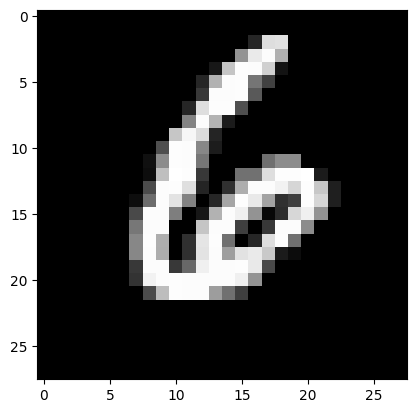

Label: 6
Length of the dataset: 60000


In [3]:
# Write some code that prints an input and output from MNIST
from torchvision import datasets
from torchvision import transforms

# Load the MNIST dataset. It's basically a list of images and their labels
mnist = datasets.MNIST(root = 'data/', train=True, transform=transforms.ToTensor(), download=True)

# TODO: Get an example image and label
idx = mnist[13]
image, label = idx

# TODO: Print the image
# Hint: The image is 1x28x28 (i.e. 1 colour channel), but plt.imshow expects a 2D image.
import matplotlib.pyplot as plt
plt.imshow(image.reshape(28, 28), cmap='gray')
plt.show()

# TODO: Print the label
print(f'Label: {label}')

# TODO: Print the length of the dataset
print(f'Length of the dataset: {len(mnist)}')

Now we need to get our data ready for training. We  split our data into `train` and `test` similarly to before, then use the `DataLoader` class from the `torch` (Pytorch) package. But this is nothing complicated - it's just a fancy list that has some special functionality for *batching* (and other things).

**Batching**: Generally, we also *batch* our inputs. This means running several values at once through the model. We then *accumulate* the gradients, and update the parameters for the entire batch at once. This is mostly for efficiency's sake, which is also the reason we don't generally run the entire datset at once through the model. You can see how this is done in the next section.

**Think🤔**: Why do you think it's more efficient to batch? After you've finished all the training code below, you can try setting the batch size to `1`, and seeing how much slower it is!

**Extension😈**: Can you think of some advantages and disadvantages of *batching* with regards to training (not with regards to efficiency)?

In [4]:
from sklearn.model_selection import train_test_split

# TODO: Split the data into training and test sets
train, test = train_test_split(mnist, test_size=0.2)

# To do batching we use the DataLoader class
from torch.utils.data import DataLoader

# TODO: Create a DataLoader for the training set. Choose a batch size! You can experiment later if it's too slow.
train_loader = DataLoader(train, batch_size=5)

# TODO: Create a DataLoader for the test set. Use the same batch size as the training set
test_loader = DataLoader(test, batch_size=5)

Now let's follow the plan. We'll start with a model, loss function and optimiser:

**Extension😈**: Do it without Pytorch!🤯 (Numpy is allowed) Don't try this unless you're really up for a challenge!

In [ ]:
input_size = 28 * 28
num_classes = 10

# TODO: Create a NN model with linear layers. It should take input_size inputs and output num_classes outputs with a ReLU activation function in between any layers.
model = nn.Sequential(
    nn.Linear(input_size, input_size)
    nn.ReLU()
    nn.Linear(input_size, input_size)
)

# TODO: Loss function is Cross Entropy Loss, it's in the nn module. Have a google!
loss_fn = ...
# Cross Entropy Loss is a loss function that is used for classification problems. It's a bit more complicated than the loss function we've been using so far, but it's very related to the one-hot encoding we talked about earlier. It's very common in 'classification' problems.
# In short, if the model gets the correct digit with 100% certainty, the loss is 0. The less certain it is, the higher the loss.
# If you want to learn more about it, check out the documentation: https://pytorch.org/docs/stable/generated/torch.nn.CrossEntropyLoss.html or Google around.

# Optimizer is torch.optim.Adam
# TODO: Create an Adam optimizer.
optimiser = ...
# This is an 'Adam' optimizer, which is a variant of gradient descent. If you want to know more about it, check out the paper: https://arxiv.org/abs/1412.6980, but it's very similar to what we've been doing so far.

Now let's train! A `for` loop over each *epoch*. In each epoch, we loop over our data loader, which loads a batch of images and labels for us. Then we follow the steps as before. Zero the gradients, compute a prediction, calculate the loss, backpropagate and update the parameters.

In this code, we also flatten the images to be 784x1 so they can be fed into our layers, rather than 28x28 (**Extension😈**: Any idea what kind of operation we could do with 28x28? Spoiler for next week!). We also record the losses so we can plot it afterwards.

In [ ]:
from tqdm import tqdm

# Set the model to training mode. This doesn't do very much for us, but it's good practice because some algorithms work differently in training than in testing.
model.train()

# We can record the loss at each step to see how the model is doing
losses = []

# Training loop
# TODO: Loop over epochs
for ...:
    # For each BATCH of images and labels
    for X, y in tqdm(train_loader):
        # TODO: Zero the gradients
        ...

        # Flatten the images from 28x28 to 1x784 so they can be fed into the model
        X = X.view(X.size(0), -1)

        # TODO: Compute the prediction
        y_pred = ...

        # TODO: Compute the loss
        loss = ...

        # TODO: Record the loss
        ...

        # TODO: Backpropagate and compute the gradients
        ...

        # TODO: Update the weights
        ...

    # Print the loss every epoch
    print(f'Epoch {epoch} Loss: {loss.item()}')

In [ ]:
# We can plot our loss over time. This can also be called the loss curve. It is a very useful graph for tracking progress through training.
plt.plot(losses)
plt.xlabel('Batch')
plt.ylabel('Loss')
plt.title('Loss over time')
plt.show()

You now have a trained model!

**Think🤔**: What does your model actually do again? What processing did the image go through? What was the output? What are all the steps it goes through?

**Extension😈**: What kind of function might your model have found? Can you describe it or draw some pictures?

*Hint: If you were programming this by hand with a single linear layer, what weights might you assing?*

Let's run our model on an example!

In [ ]:
# TODO: Get an image and label from mnist at an index
index = ...
image, label = mnist[index]
image_transformed = image.view(image.size(0), -1)

# TODO: Compute the output of the model
output = ...

# TODO: Compute the predicted label. Hint: We output a vector of length 10, where each element is the probability of the image being that digit. We want the digit with the highest probability.
predicted_label = ...

# TODO: Print the image
plt.imshow(..., cmap='gray')

plt.show()
print(f'Predicted Label: {predicted_label}')
print(f'True Label: {label}')

Evaluating one data point at a time is not very efficient. Let's compute the overall accuracy on both the testing and training sets separately.

**Think🤔**: What other metrics might be useful here? Why is accuracy probably okay to use here compared to the google hiring problem? What problems might we run into if there are very few 9's in the dataset?

In [ ]:
from sklearn.metrics import accuracy_score

# Set the mode to evaluation mode
model.eval()

# Predict the test set
y_pred = []
y_test = []
# TODO: Loop over the test loader.
for X, y in tqdm(...):
    X = X.view(X.size(0), -1)
    # TODO: Compute the predictions and append them to y_pred. Why are we using extend instead of append?
    y_pred.extend(...)
    # TODO: Append the true labels to y_test
    y_test.extend(...)

# TODO: Compute the accuracy using the accuracy_score function from sklearn
accuracy = ...
print(f'Accuracy: {accuracy}')


In [ ]:
# We can also get our accuracy on the training set
y_pred = []
y_train = []
# TODO: Loop over the training loader.
for X, y in tqdm(...):
    X = X.view(X.size(0), -1)
    # TODO: Compute the predictions and append them to y_pred
    y_pred.extend(...)
    # TODO: Append the true labels to y_train
    y_train.extend(...)

# TODO: Compute the accuracy on the training set
accuracy = ...
print(f'Accuracy: {accuracy}')

**Think🤔**: Which accuracy is higher or are they similar? *Should* they be similar? What would be ideal? What if you only trained your model on one data sample? What if you trained it on one data sample 1000 times? What do you think your train/test accuracies would be?

**Extension😈**: Try using a model with 3 layers that goes from
`input_size` to 128 neurons, to 64 neurons, to 10 neurons. Then train it for 100 epochs! What do you expect the train and test accuracies to do? Is that what happens?

These exercises allude to the concepts of undertraining and overtraining (or underfitting and overfitting). What do you think these words mean? If you want to learn more, you can google 'bias and variance tradeoff'.

**Extension😈**: Try applying just linear regression to this problem. You could even do this with Pytorch! - but think about how and why would it be different to using sklearn's `LinearRegression`. How good do you think it would be? Why? Try it out and test your hypothesis!

*Hint: How identifiable do you think a digit is by **just** it pixels? What is the difference between gradient descent and OLS?*

In [ ]:
# TODO: Try it out with just Linear Regression!

...

## Machine Learning ✅

> That's it! Well done - you've started your ML journey. I hope you can see why this is such a cool field of research, and why it's so incredibly useful. Go get reading & building, and I'll see you at the next workshop for some more advanced computer vision 🚀
>
> P.S Go watch 3Blue1Brown's series on Deep Learning. If you've watched it before, watch it again, you might get something differnt out of it now!

Pierre Mackenzie, Edinburgh AI